In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\Real World ML Projects\loan-risk-prediction\data\raw\loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


: 

In [15]:
df.columns = df.columns.str.strip()

In [ ]:
df.shape

(4269, 13)

: 

In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

: 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


: 

In [ ]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

: 

In [16]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

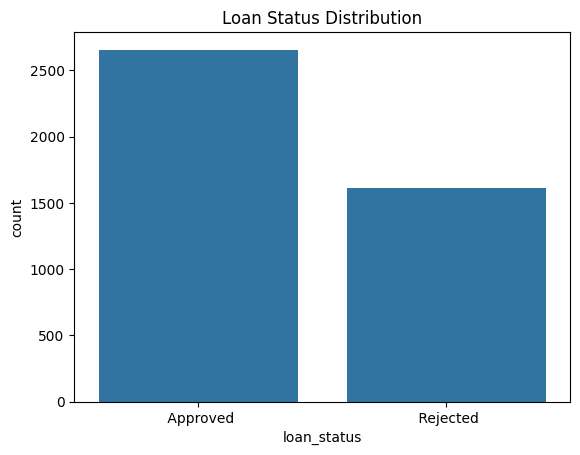

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

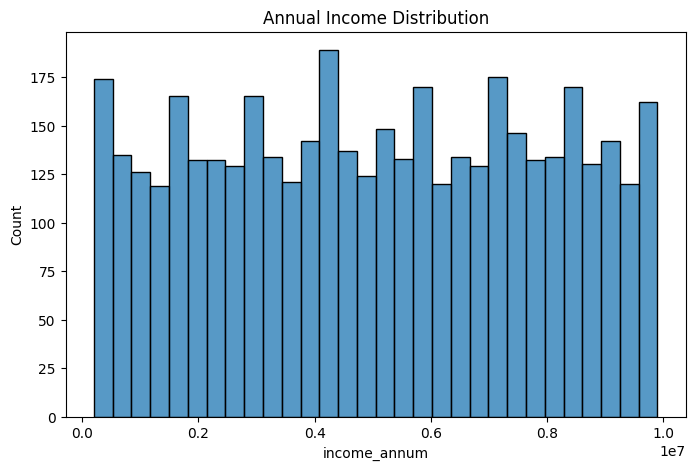

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["income_annum"], bins=30)
plt.title("Annual Income Distribution")
plt.show()

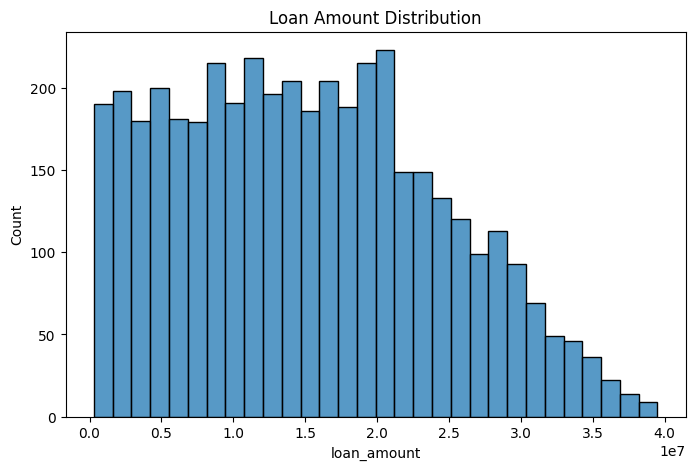

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["loan_amount"], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

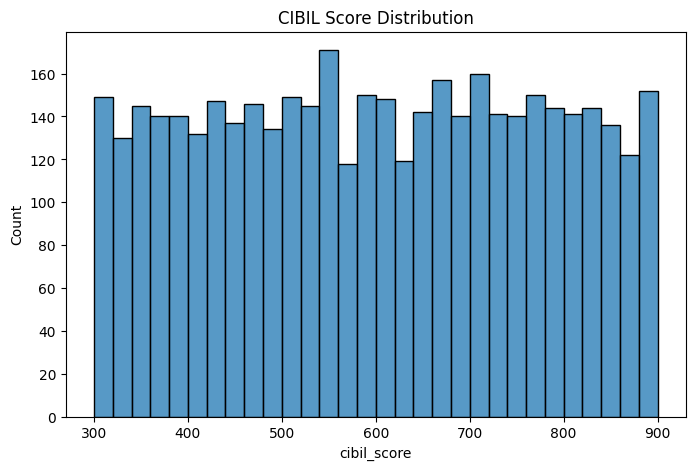

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["cibil_score"], bins=30)
plt.title("CIBIL Score Distribution")
plt.show()

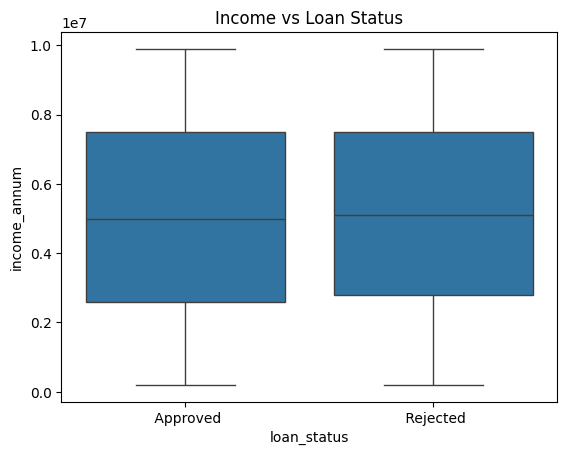

In [22]:
sns.boxplot(x="loan_status", y="income_annum", data=df)
plt.title("Income vs Loan Status")
plt.show()

Observation:

The distribution of annual income for approved and rejected loans appears very similar.
The median income for both categories is almost the same.

This suggests that income alone does not strongly influence loan approval decisions.
Other factors such as credit score, asset values, and loan amount may play a more
important role in determining loan approval.

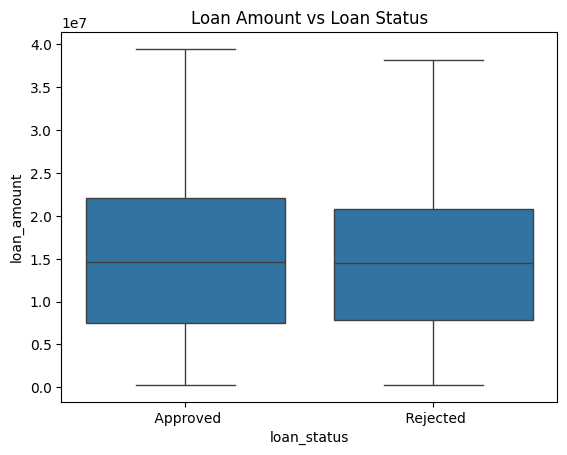

In [23]:
sns.boxplot(x="loan_status", y="loan_amount", data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

Observation:

The distribution of loan amounts for approved and rejected loans is very similar.
Both categories show nearly identical median values and spread.

This indicates that loan amount alone does not significantly influence loan approval decisions.
Banks likely consider additional factors such as income, credit score, and asset values when evaluating loan applications.

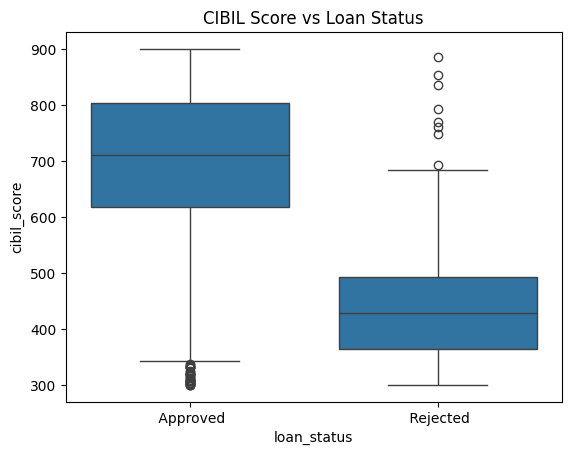

In [24]:
sns.boxplot(x="loan_status", y="cibil_score", data=df)
plt.title("CIBIL Score vs Loan Status")
plt.show()

Observation:

CIBIL score shows a strong relationship with loan approval.

Applicants with higher CIBIL scores (around 650–800) are significantly more
likely to have their loans approved, while applicants with lower scores
(around 300–500) are more frequently rejected.

This indicates that CIBIL score is one of the most important factors
in determining loan approval decisions.

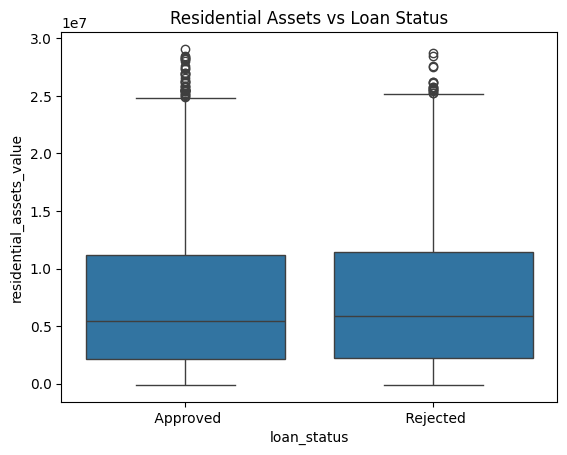

In [28]:
sns.boxplot(x="loan_status", y="residential_assets_value", data=df)
plt.title("Residential Assets vs Loan Status")
plt.show()

Observation:

The distribution of residential asset values for approved and rejected loans
appears very similar. Both groups show nearly identical median values and
spread.

This suggests that residential asset value alone does not strongly influence
loan approval decisions. Banks likely evaluate the overall financial profile
of applicants, including income, credit score, and total assets.

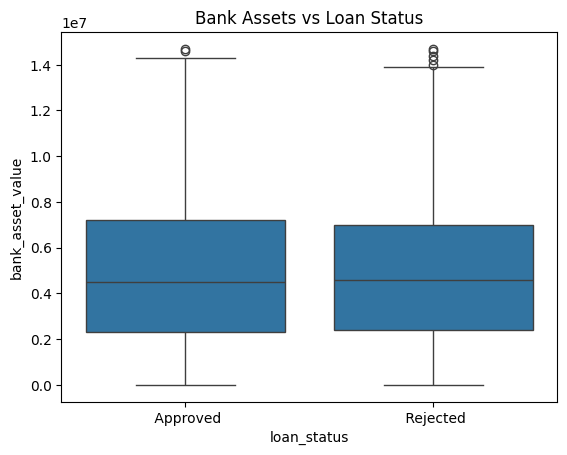

In [29]:
sns.boxplot(x="loan_status", y="bank_asset_value", data=df)
plt.title("Bank Assets vs Loan Status")
plt.show()

Observation:

The distribution of bank asset values for approved and rejected loans
appears very similar. Both categories show nearly identical median values
and spread.

This suggests that bank asset value alone does not strongly influence loan
approval decisions. Instead, banks likely evaluate a combination of factors
such as credit score, income, loan amount, and total assets when assessing
loan applications.

In [25]:
numeric_df = df.select_dtypes(include=["int64","float64"])

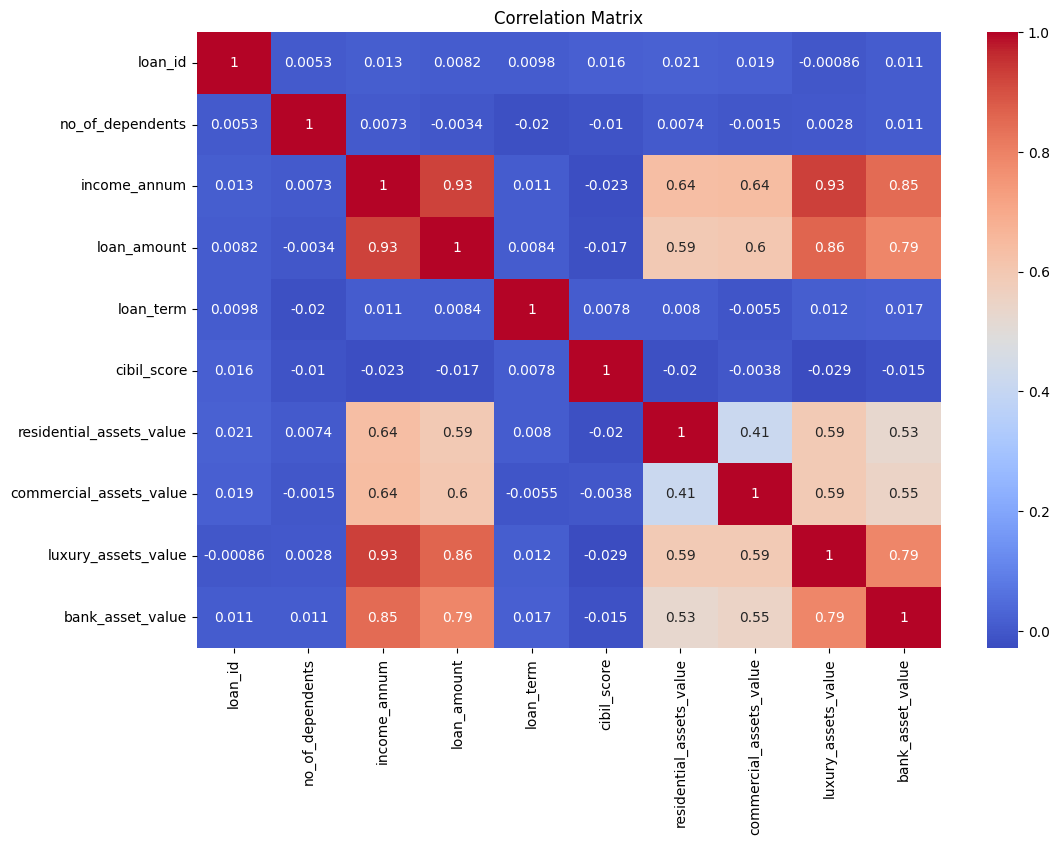

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Insights from Correlation Analysis:

1. Income shows a very strong positive correlation with loan amount (0.93), indicating
   that individuals with higher income tend to take larger loans.

2. Income is also strongly correlated with luxury and bank asset values, suggesting
   that wealthier individuals possess higher-value assets.

3. Loan amount is moderately to strongly correlated with asset values, indicating
   that banks may consider asset ownership when granting larger loans.

4. CIBIL score appears largely independent of income and asset variables, suggesting
   that creditworthiness is influenced more by financial behavior than wealth.

5. Loan ID is an identifier and will not be used as a feature in model training.

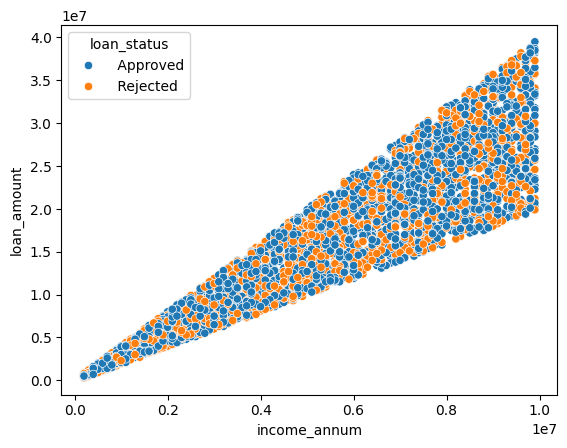

In [27]:
sns.scatterplot(x="income_annum", y="loan_amount", hue="loan_status", data=df)
plt.show()

Observation:

The scatter plot shows a strong positive relationship between income and loan amount,
indicating that applicants with higher income tend to receive larger loan amounts.

However, both approved and rejected loan applications appear across the entire range
of income and loan values, suggesting that these two features alone are not sufficient
to determine loan approval.

This indicates that other factors such as credit score and asset values likely play
a more significant role in the loan approval decision.

# EDA Conclusion

The exploratory data analysis was conducted to understand the dataset structure, feature relationships, and factors influencing loan approval decisions.

Key observations from the analysis include:

* **CIBIL score** shows the strongest relationship with loan approval. Applicants with higher credit scores are more likely to get approved.
* **Income and loan amount** have a strong positive correlation, indicating that higher income applicants tend to take larger loans.
* **Asset-related features** (residential, commercial, luxury, and bank assets) show moderate relationships with income and loan amount but do not individually determine loan approval.
* **Loan ID** is only an identifier and will not be used for model training.

Overall, the analysis suggests that **credit score combined with financial indicators such as income, assets, and loan amount** will play an important role in predicting loan approval. Feature engineering will be performed next to create more informative variables for model training.
